Projeto - análise de dados de uma loja fictícia.

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\Murilo\Documents\projetos\vendas_loja_ficticia.csv")

In [4]:
print(df.head)

<bound method NDFrame.head of           Data  Produto   Categoria   Preço  Quantidade          Cidade  \
0   2024-04-12    Tênis    Calçados  437.18           3        Curitiba   
1   2024-06-28   Camisa      Roupas  162.61           1       São Paulo   
2   2024-04-02    Tênis    Calçados   67.48           3          Recife   
3   2024-01-15  Jaqueta      Roupas  186.47           4       São Paulo   
4   2024-04-16    Calça      Roupas  291.69           4       São Paulo   
..         ...      ...         ...     ...         ...             ...   
95  2024-03-03    Calça      Roupas  238.08           2       São Paulo   
96  2024-05-18     Boné  Acessórios  485.41           3       São Paulo   
97  2024-03-21     Boné  Acessórios  296.59           2  Belo Horizonte   
98  2024-05-15  Relógio  Acessórios  240.56           2        Curitiba   
99  2024-06-11    Calça      Roupas  305.83           1        Curitiba   

   Pagamento  Avaliação    Total  
0   Dinheiro          5  1311.54  

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Data        100 non-null    object 
 1   Produto     100 non-null    object 
 2   Categoria   100 non-null    object 
 3   Preço       100 non-null    float64
 4   Quantidade  100 non-null    int64  
 5   Cidade      100 non-null    object 
 6   Pagamento   100 non-null    object 
 7   Avaliação   100 non-null    int64  
 8   Total       100 non-null    float64
dtypes: float64(2), int64(2), object(5)
memory usage: 7.2+ KB
None


Receita total

In [6]:
receita_total = df['Total'].sum()
print(f"Receita total é {receita_total:,.2f}.")

Receita total é 62,739.91.


Produtos mais vendidos 

In [7]:
produtos_mais_vendidos = df.groupby('Produto')['Quantidade'].sum().sort_values(ascending=False)

In [8]:
print(produtos_mais_vendidos)

Produto
Tênis      51
Camisa     49
Relógio    44
Boné       44
Calça      27
Jaqueta    25
Name: Quantidade, dtype: int64


Cidades com maior faturamento

In [9]:
cidade_faturamento =  df.groupby('Cidade')['Total'].sum().sort_values(ascending=False)

In [10]:
print(cidade_faturamento)

Cidade
Belo Horizonte    17108.61
Curitiba          16169.68
São Paulo         15328.71
Rio de Janeiro     8592.15
Recife             5540.76
Name: Total, dtype: float64


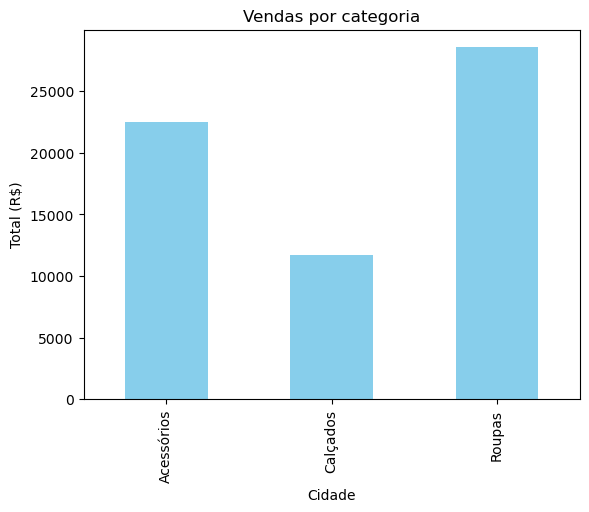

In [11]:
df.groupby('Categoria')['Total'].sum().plot(kind= 'bar', color= 'skyblue')
plt.title('Vendas por categoria')
plt.ylabel('Total (R$)')
plt.xlabel('Cidade')
plt.show()

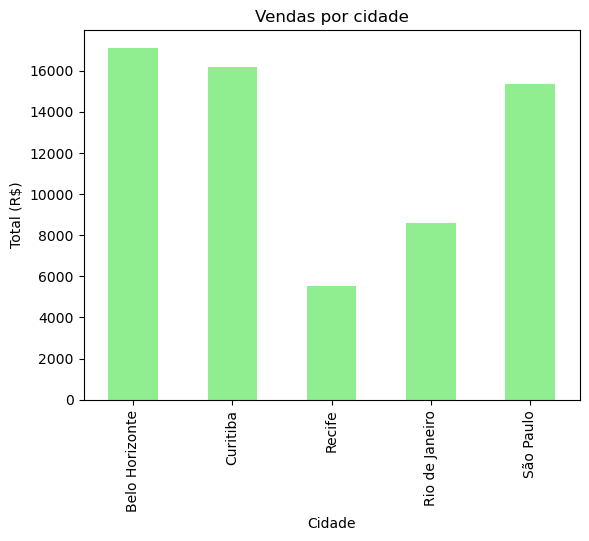

In [12]:
df.groupby('Cidade')['Total'].sum().plot(kind= 'bar', color= 'lightgreen')
plt.title('Vendas por cidade')
plt.ylabel('Total (R$)')
plt.xlabel('Cidade')
plt.show()

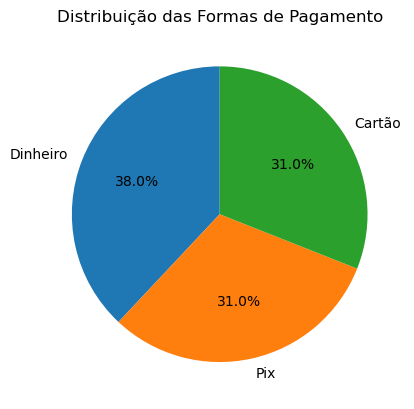

In [16]:
df['Pagamento'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Distribuição das Formas de Pagamento')
plt.ylabel('')
plt.show()

Análise das vendas ao longo do tempo

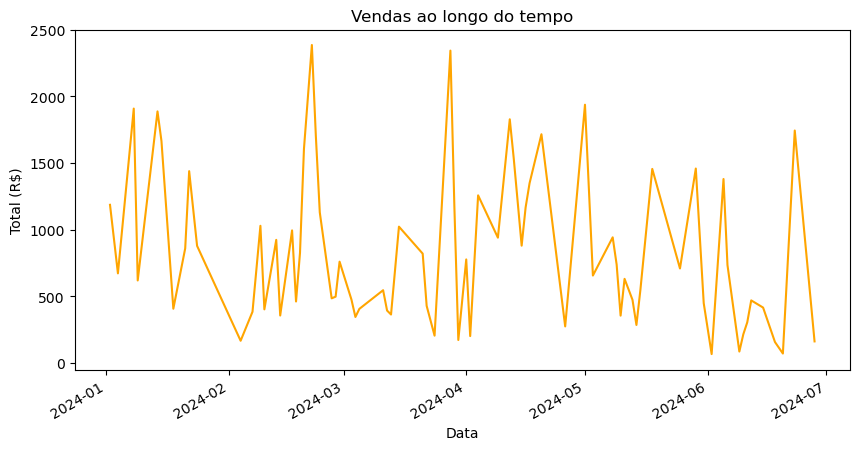

In [21]:
df['Data'] = pd.to_datetime(df['Data'], format='%d/%m/%Y')

vendas_diarias = df.groupby('Data')['Total'].sum()

vendas_diarias.plot(figsize=(10,5), color='orange')
plt.title('Vendas ao longo do tempo')
plt.xlabel('Data')
plt.ylabel('Total (R$)')
plt.show()